In [49]:
import pandas as pd
import yaml
import os

DATA_DIR = "D:\\data\\DATA2"

users_path = os.path.join(DATA_DIR, "users.csv")
users_df = pd.read_csv(users_path)
users_df = users_df.drop_duplicates()

orders_path = os.path.join(DATA_DIR, "orders.parquet")
orders_df = pd.read_parquet(orders_path)
orders_df = orders_df.drop_duplicates()

books_path = os.path.join(DATA_DIR, "books.yaml")
with open(books_path, 'r') as file:
    books_data = yaml.safe_load(file)

books_df = pd.DataFrame(books_data)
books_df.columns = [col.strip(':') if isinstance(col, str) else col for col in books_df.columns]
books_df = books_df.drop_duplicates()

print("Users shape:", users_df.shape)
print("Orders shape:", orders_df.shape)
print("Books shape:", books_df.shape)

Users shape: (2810, 5)
Orders shape: (9850, 7)
Books shape: (741, 6)


In [50]:
users_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2810 entries, 0 to 2809
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   id       2810 non-null   int64 
 1   name     2810 non-null   object
 2   address  2713 non-null   object
 3   phone    2810 non-null   object
 4   email    2810 non-null   object
dtypes: int64(1), object(4)
memory usage: 109.9+ KB


In [51]:
users_df['address'] = users_df['address'].fillna('Unknown')

In [52]:
count = users_df.isna().sum()
print(count)

id         0
name       0
address    0
phone      0
email      0
dtype: int64


In [53]:
count1 = (users_df.values =="").sum()
count2 = (users_df.values=="NULL").sum()
print(count1)
print(count2)

0
0


In [54]:
users_df

,id,name,address,phone,email
0,53386,Jacqulyn Mante,"566 Emelina Turnpike, Lashundaside, NE 78034-5281",962.715.8009,leonardo.leannon@wintheiser-lueilwitz.example
1,54635,Devon Leannon III,,(537) 133-9394,jon_torp@bayer.example
2,55435,Shiloh Keebler,"425 Wesley Hills, Nathanialburgh, MS 08004",474.242.3397,murray_mcclure@pfeffer.example
3,53627,Luke Rolfson,"Suite 556 20616 Little Union, Connieside, VT 3...",927.381.8818,murray.shanahan@heathcote.example
4,55650,Prince Braun,"981 Howell Spring, New Sheldon, LA 62246-1232",686-186-1306,anitra@pollich-kris.example
...,...,...,...,...,...
2805,54394,Roman Lakin,"390 Eugena Burgs, West Elbert, NM 20025",(561) 924-3672,arnold_gulgowski@stracke.example
2806,54468,Sherly Ziemann Jr.,"50831 Hobert Parkway, Ruthstad, CT 03992",989.449.3065,keven@barrows.test
2807,53319,Magda Krajcik,"21479 Ashley Coves, Nakishaview, WY 03080-2928",488 907 3434,grover_predovic@wolf-parisian.test
2808,54890,Major Kuhn II,"47547 Hansen Circles, Port Cedric, DE 44484",348 595 5961,sterling_konopelski@reichel.test


In [55]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9850 entries, 0 to 9849
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          9850 non-null   int64 
 1   user_id     9850 non-null   int64 
 2   book_id     9850 non-null   int64 
 3   quantity    9850 non-null   int32 
 4   unit_price  9850 non-null   object
 5   timestamp   9850 non-null   object
 6   shipping    7467 non-null   object
dtypes: int32(1), int64(3), object(3)
memory usage: 500.3+ KB


In [56]:
count1 = (orders_df['shipping']=="").sum()
count2 = (orders_df['shipping']=="NULL").sum()
count3 = orders_df['shipping'].isna().sum()
print(count1)
print(count2)
print(count3)

2438
2496
2383


In [57]:
import numpy as np
orders_df = orders_df.replace("", np.nan)
orders_df = orders_df.replace("NULL", np.nan)

In [58]:
count4 = orders_df.isna().sum()
print(count4)

id               0
user_id          0
book_id          0
quantity         0
unit_price       0
timestamp        0
shipping      7317
dtype: int64


In [59]:
orders_df['shipping'] = orders_df['shipping'].fillna('Unknown')

In [60]:
count = orders_df.isna().sum()
print(count)

id            0
user_id       0
book_id       0
quantity      0
unit_price    0
timestamp     0
shipping      0
dtype: int64


In [61]:
from dateutil import parser
orders_df['date'] = orders_df['timestamp'].apply(
    lambda x: parser.parse(x.replace(';', ' ').replace(',', ' ')).date() if pd.notnull(x) else pd.NaT
)

c:\Users\Samiz\anaconda3\envs\myenv\Lib\site-packages\dateutil\parser\_parser.py:1207: UnknownTimezoneWarning: tzname M identified but not understood.  Pass `tzinfos` argument in order to correctly return a timezone-aware datetime.  In a future version, this will raise an exception.
  warnings.warn("tzname {tzname} identified but not understood.  "


In [62]:
orders_df

,id,user_id,book_id,quantity,unit_price,timestamp,shipping,date
0,75198,55590,21465,1,73.5$,"08:47:31 P.M.,10/07/24",Unknown,2024-10-07
1,82023,53482,21374,1,$25.00,2024-09-11T05:27:49,Unknown,2024-09-11
2,81439,55123,21408,1,USD22.50,"2024-08-06,06:53",Unknown,2024-08-06
3,80259,54387,21013,1,42.5$,03/18/25;09:32:41 AM,Unknown,2025-03-18
4,80176,54916,21437,1,$ 62.5,"04:55:14 pm,09/24/24",Unknown,2024-09-24
...,...,...,...,...,...,...,...,...
9845,82877,55305,21019,3,61 USD,"10:34:00 A.M.,2024-12-10",Unknown,2024-12-10
9846,77777,55425,21529,1,63.0 USD,"08/08/24,09:00:04 AM",Unknown,2024-08-08
9847,77993,54536,21045,2,23.50 $,05:44:05 pm 10/12/24,Unknown,2024-10-12
9848,82157,54598,21509,1,USD14.0,2024-11-13T16:06:23.816,Unknown,2024-11-13


In [63]:
import re
import pandas as pd

def convert_to_usd(price_val):
    if pd.isna(price_val):
        return 0.0
        
    price_str = str(price_val).strip()
    is_euro = '€' in price_str or 'EUR' in price_str.upper()
    price_str = re.sub(r'(\d+)[$¢€](\d+)¢?', r'\1.\2', price_str)
    numeric_str = re.sub(r'[^\d.]', '', price_str)

    if not numeric_str:
        return 0.0

    if is_euro:
        val = float(numeric_str) * 1.2
    else:
        val = float(numeric_str)
        
    return val

orders_df['unit_price_usd'] = orders_df['unit_price'].apply(convert_to_usd)
orders_df['paid_price'] = (orders_df['quantity'] * orders_df['unit_price_usd']).round(2)
print(orders_df[['quantity', 'unit_price', 'unit_price_usd', 'paid_price']].tail(50))

      quantity unit_price  unit_price_usd  paid_price
9800         1     USD 68          68.000       68.00
9801         1     31 EUR          37.200       37.20
9802         2     50$25¢          50.250      100.50
9803         1  18.00 USD          18.000       18.00
9804         2    31.50 $          31.500       63.00
9805         2      $67.5          67.500      135.00
9806         1   USD41.75          41.750       41.75
9807         1       19 $          19.000       19.00
9808         1     17.50$          17.500       17.50
9809         1   31.00USD          31.000       31.00
9810         1     €67.99          81.588       81.59
9811         2   43.25EUR          51.900      103.80
9812         1     €42¢50          51.000       51.00
9813         1      $36.0          36.000       36.00
9814         1      32.0$          32.000       32.00
9815         3  20.99 EUR          25.188       75.56
9816         1      $16.5          16.500       16.50
9817         1       € 24   

In [64]:
books_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 741 entries, 0 to 740
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         741 non-null    int64 
 1   title      741 non-null    object
 2   author     741 non-null    object
 3   genre      741 non-null    object
 4   publisher  735 non-null    object
 5   year       739 non-null    object
dtypes: int64(1), object(5)
memory usage: 34.9+ KB


In [65]:
count1 = (books_df['publisher']=="").sum()
count2 = (books_df['publisher']=="NULL").sum()
count3 = books_df['publisher'].isna().sum()
print(count1)
print(count2)
print(count3)

4
1
6


In [66]:
books_df = books_df.replace("", np.nan)
books_df = books_df.replace("NULL", np.nan)

In [67]:
count1 = (books_df['year']=="").sum()
count2 = (books_df['year']=="NULL").sum()
count3 = books_df['year'].isna().sum()
print(count1)
print(count2)
print(count3)

0
0
3


In [68]:
books_df['publisher'] = books_df['publisher'].fillna('Unknown')
books_df['year'] = books_df['year'].fillna('Unknown')

In [69]:
count = books_df.isna().sum()
print(count)

id           0
title        0
author       0
genre        0
publisher    0
year         0
dtype: int64


In [70]:
books_df

,id,title,author,genre,publisher,year
0,21326,Behold the Man,"Trenton Sipes, Clint Hauck VM",Reference book,Bowes & Bowes,1979
1,21546,The Deer Hunter,Norris Gusikowski,Reference book,Koren Publishers Jerusalem,1993
2,21130,Snatch,Rev. Lura Jaskolski,Fable,Left Book Club,2000
3,21287,Dial M for Murder,Miss Elmo Walsh,Textbook,Libertas Academica,1977
4,21237,The Departed,Mario Aufderhar,Folklore,BBC Books,2015
...,...,...,...,...,...,...
736,21002,Commandos: Beyond the Call of Duty,Noma Kris VM,Fiction narrative,Banner of Truth Trust,1987
737,21045,Pokémon FireRed,Rep. Albert Stamm,Legend,Ian Allan Publishing,2001
738,20972,The Maltese Falcon,Coy Hegmann,Essay,Schocken Books,2005
739,20935,Oldeuboi,Virgilio Bernier,Legend,Papadakis Publisher,1922


In [71]:
daily_revenue = orders_df.groupby('date')['paid_price'].sum().reset_index()
daily_revenue.rename(columns={'paid_price': 'daily_revenue'}, inplace=True)
print(daily_revenue)

           date  daily_revenue
0    2023-12-24          51.90
1    2023-12-26          23.40
2    2024-01-07         345.60
3    2024-01-08         370.50
4    2024-01-09          24.50
..          ...            ...
625  2025-11-04          91.50
626  2025-11-05          29.40
627  2025-11-07          49.00
628  2025-12-01          63.00
629  2025-12-03          24.25

[630 rows x 2 columns]


In [72]:
top_5_revenue_days = daily_revenue.sort_values(by='daily_revenue', ascending=False).head(5)
print("Top 5 Days by Revenue:")
print(top_5_revenue_days.to_string(index=False))

Top 5 Days by Revenue:
      date  daily_revenue
2024-09-12        4048.85
2024-11-15        3677.17
2024-11-21        3590.09
2024-12-25        3572.11
2025-01-20        3561.50


In [73]:
def normalize(col):
    return col.astype(str).str.strip().str.lower()

users_df['name'] = normalize(users_df['name'])
users_df['address'] = normalize(users_df['address'])
users_df['phone'] = normalize(users_df['phone'])
users_df['email'] = normalize(users_df['email'])

n = len(users_df)
parent = list(range(n))

def find(x):
    if parent[x] != x:
        parent[x] = find(parent[x])
    return parent[x]

def union(x, y):
    px, py = find(x), find(y)
    if px != py:
        parent[py] = px

def merge_on_columns(cols):
    groups = users_df.groupby(cols).indices
    for _, indices in groups.items():
        indices = list(indices)
        for i in range(1, len(indices)):
            union(indices[0], indices[i])

merge_on_columns(['name', 'address', 'phone'])
merge_on_columns(['name', 'address', 'email'])
merge_on_columns(['name', 'phone', 'email'])
merge_on_columns(['address', 'phone', 'email'])

unique_users = len(set(find(i) for i in range(n)))
print("Number of real unique users:", unique_users)

Number of real unique users: 2663


In [74]:
def get_author_set(author_string):
    raw_authors = str(author_string).split(',')
    cleaned_authors = [author.strip() for author in raw_authors if author.strip()]
    sorted_authors = sorted(cleaned_authors)
    return tuple(sorted_authors)

normalized_author_sets = books_df['author'].apply(get_author_set)
unique_sets_count = normalized_author_sets.nunique()

print(f"Number of unique sets of authors: {unique_sets_count}")
print("\nSample of unique author sets:")
print(pd.Series(normalized_author_sets.unique()))

Number of unique sets of authors: 293

Sample of unique author sets:
0         (Clint Hauck VM, Trenton Sipes)
1                    (Norris Gusikowski,)
2                  (Rev. Lura Jaskolski,)
3                      (Miss Elmo Walsh,)
4                      (Mario Aufderhar,)
                      ...                
288                       (Cindie Boyer,)
289                   (Kelle Bartoletti,)
290                (Fr. Torie Schneider,)
291                (Msgr. Santo Schuppe,)
292    (Avery Zemlak, Mrs. Chelsie Weber)
Length: 293, dtype: object


In [75]:
books_df['author_set'] = books_df['author'].apply(get_author_set)
merged_df = orders_df.merge(books_df[['id', 'author_set']], left_on='book_id', right_on='id', how='inner')
author_set_sales = merged_df.groupby('author_set')['quantity'].sum().reset_index()
top_author_sets = author_set_sales.sort_values(by='quantity', ascending=False)
most_popular = top_author_sets.iloc[0]

print("Top 5 Author Sets by Sales")
print(top_author_sets.head(5).to_string(index=False))
print(f"The most popular author set is {most_popular['author_set']}")

Top 5 Author Sets by Sales
                                                             author_set  quantity
              (Hershel Treutel, Miss Modesto Denesik, Sen. Trula Bosco)       163
                                                       (Jaimie Skiles,)       146
(Adrian Stroman PhD, Hilario Legros I, Marco Cormier, Morton Goodwin I)       143
                                                    (Brianna O'Conner,)       136
                           (Carma Mayer DC, Hank Huel, Rev. Ben Nienow)       125
The most popular author set is ('Hershel Treutel', 'Miss Modesto Denesik', 'Sen. Trula Bosco')


In [76]:
users_df['real_user_id'] = [users_df.at[find(i), 'id'] for i in range(n)]
id_to_real_id = dict(zip(users_df['id'], users_df['real_user_id']))
orders_df['real_user_id'] = orders_df['user_id'].map(id_to_real_id)

valid_orders = orders_df.dropna(subset=['real_user_id'])
user_spending = valid_orders.groupby('real_user_id')['paid_price'].sum().reset_index()

top_customer = user_spending.sort_values(by='paid_price', ascending=False).iloc[0]
top_real_user_id = top_customer['real_user_id']
best_buyer_aliases = users_df[users_df['real_user_id'] == top_real_user_id]['id'].tolist()

print(f"Best buyer (user_ids): {best_buyer_aliases}")

Best buyer (user_ids): [53583, 55058, 55420]


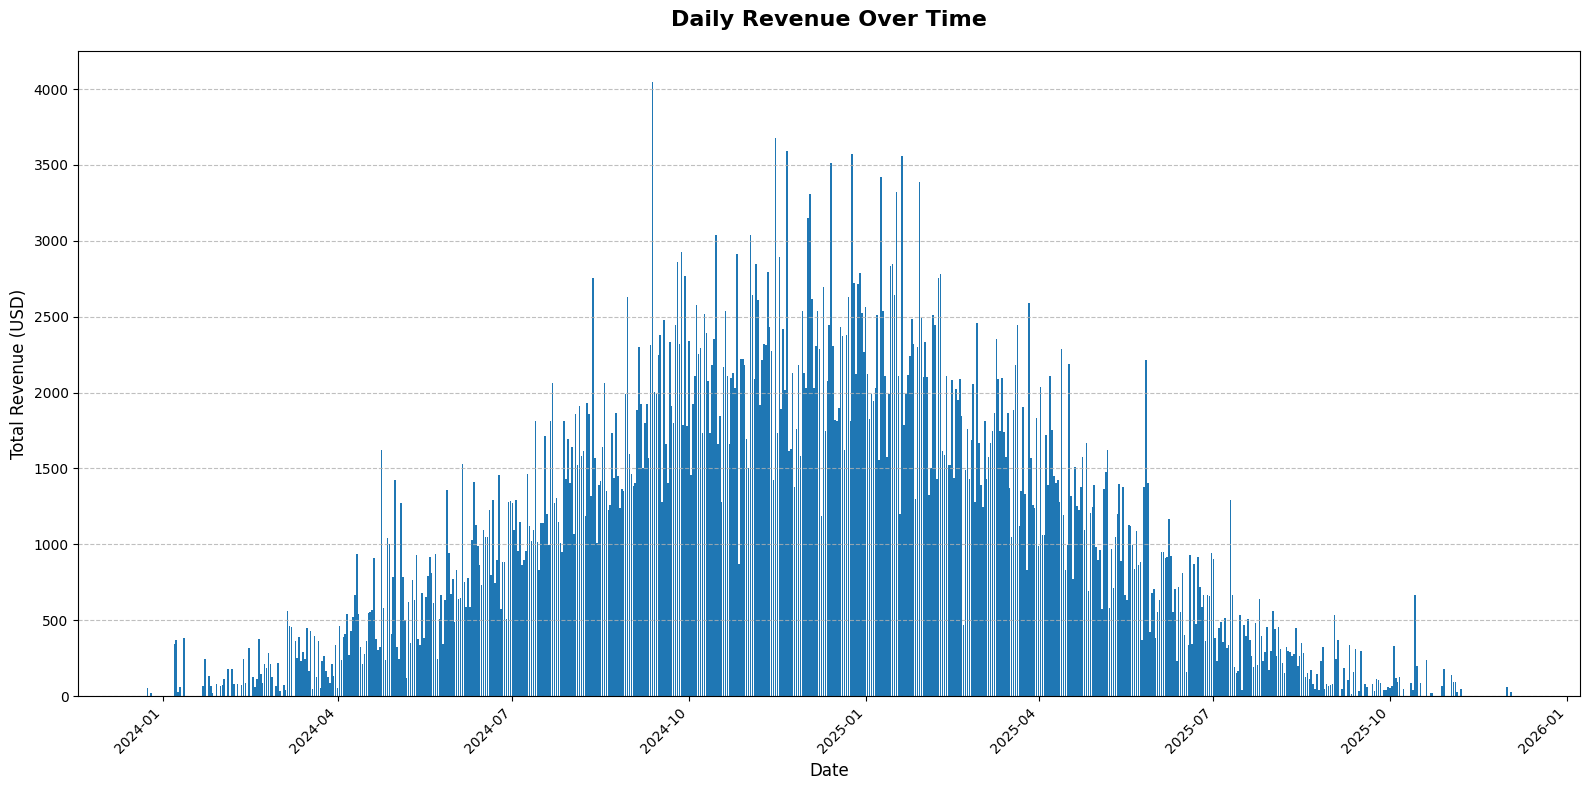

In [77]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16, 8))
ax.bar(
    daily_revenue['date'], 
    daily_revenue['daily_revenue'], 
    color='#1f77b4'
)

ax.set_title('Daily Revenue Over Time', fontsize=16, fontweight='bold', pad=18)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Total Revenue (USD)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.8, axis='y')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

In [78]:
import json

dataset_name = "DATA2"
daily_revenue.to_csv(f'daily_revenue_{dataset_name}.csv', index=False)
top_5_revenue_days.to_csv(f'top_5_revenue_{dataset_name}.csv', index=False)

metrics = {
    "unique_users": int(unique_users),
    "unique_author_sets": int(unique_sets_count),
    "most_popular_author": str(most_popular['author_set']),
    "best_buyer_aliases": best_buyer_aliases 
}

with open(f'dashboard_metrics_{dataset_name}.json', 'w') as f:
    json.dump(metrics, f)